# Predictive Models v2 — Improved Text & Sentiment Features

**What changed vs v1?**

| Change | Reason |
|--------|--------|
| Target = `price_change` (delta price) instead of price level | AR(1) no longer a "free lunch"; models must learn genuine signal |
| Relative sentiment features | The *difference* Trump-Harris is more predictive than either alone |
| Sentiment surprise = deviation from 7-day rolling mean | Markets react to *unexpected* sentiment shifts, not stable levels |
| Poll momentum = `poll_margin_change` | Direction of poll movement matters, not just the level |
| Interaction term: sentiment gap x poll margin | Combined signal from social media + polls |
| Candidate-specific text columns (6 instead of 3) | Focused Trump/Harris sentences -> less noise per TF-IDF document |
| TF-IDF: `min_df=1, max_features=200, n_components=5` | Better coverage for small corpus (35-80 training days per fold) |


## Setup

In [1]:
import sys, os, warnings, itertools
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available")

from Functions.data_splits import get_cv_folds, get_test_split, validate_no_leakage, print_fold_summary
from Descriptive.house_style import (apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    REPUBLICAN, DEMOCRAT, NEUTRAL, PALETTE)
apply_style()
print("Setup OK")

Setup OK


## Load data

In [2]:
df = pd.read_csv('../Data/3_Gold/basetable.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

try:
    text_raw = pd.read_csv('../Data/3_Gold/text_raw_daily.csv', parse_dates=['date'])
    for col in ['bsky_text', 'reddit_text', 'news_text']:
        text_raw[col] = text_raw[col].fillna('')
    df = df.merge(text_raw[['date','bsky_text','reddit_text','news_text']],
                  on='date', how='left')
    for col in ['bsky_text','reddit_text','news_text']:
        df[col] = df[col].fillna('')
    HAS_TEXT = True
    print(f"Raw text merged: {text_raw.shape}")
except FileNotFoundError:
    print("text_raw_daily.csv not found -- run text_features.ipynb first")
    HAS_TEXT = False

print(f"Basetable shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")

Raw text merged: (124, 4)
Basetable shape: (124, 100)
Date range: 2024-07-05 -> 2024-11-05


## Feature engineering

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# All new features are strictly backward-looking (no future leakage).
# shift(1) ensures feature at row t uses data from t-1 or earlier.
# ─────────────────────────────────────────────────────────────────────────────

# 1. RELATIVE SENTIMENT — Trump minus Harris
#    Rationale: markets respond to the *gap* between candidates.
df['bsky_sentiment_gap'] = df['bsky_trump_sentiment_avg'] - df['bsky_harris_sentiment_avg']
df['news_sentiment_gap'] = df['news_trump_sentiment_avg'] - df['news_harris_sentiment_avg']

# 2. SENTIMENT SURPRISE — deviation from 7-day rolling mean
#    Rationale: a surprise (large positive deviation from recent mean)
#    may move the market tomorrow. We shift(1) so the feature at row t
#    uses yesterday's surprise (fully known at prediction time).
for col, new in [('bsky_trump_sentiment_avg', 'bsky_sent_surprise'),
                 ('news_trump_sentiment_avg',  'news_sent_surprise'),
                 ('bsky_sentiment_gap',        'bsky_gap_surprise')]:
    rolling_mean = df[col].shift(1).rolling(7, min_periods=3).mean()
    df[new] = df[col].shift(1) - rolling_mean

# 3. POLL MOMENTUM — 1-day change in poll margin
df['poll_margin_change'] = df['poll_margin'].diff().shift(1)

# 4. ATTENTION ASYMMETRY — maps [0,1] share to [-1,+1]
df['bsky_attention_asymmetry'] = 2 * df['bsky_trump_post_share'] - 1

# 5. INTERACTION — sentiment gap x poll margin (confluence of signals)
df['interaction_sent_x_poll'] = df['bsky_sentiment_gap'].shift(1) * df['poll_margin']

# 6. CANDIDATE-SPECIFIC TEXT COLUMNS
#    Filter raw text to sentences mentioning each candidate.
#    Focused documents reduce TF-IDF noise for small corpora.
if HAS_TEXT:
    def filter_sentences(text, keywords):
        sentences = [s.strip() for s in text.replace('\n', '. ').split('.') if s.strip()]
        return ' '.join(s for s in sentences
                       if any(k in s.lower() for k in keywords))

    TRUMP_KW  = ['trump', 'donald', 'maga', 'republican']
    HARRIS_KW = ['harris', 'kamala', 'democrat', 'walz']

    for src in ['bsky', 'reddit', 'news']:
        raw_col = f'{src}_text'
        df[f'{src}_trump_text']  = df[raw_col].apply(
            lambda x: filter_sentences(x, TRUMP_KW))
        df[f'{src}_harris_text'] = df[raw_col].apply(
            lambda x: filter_sentences(x, HARRIS_KW))

    TEXT_COLS = [f'{src}_{cand}_text'
                 for src in ['bsky','reddit','news']
                 for cand in ['trump','harris']]
    print(f"Candidate-specific text columns ({len(TEXT_COLS)}):")
    for col in TEXT_COLS:
        empty = (df[col] == '').sum()
        avg_w = df[col].apply(lambda x: len(x.split())).mean()
        print(f"  {col:<30} avg {avg_w:5.0f} words/day  {empty} empty days")
else:
    TEXT_COLS = []

print("\nNew numeric features added:")
new_feats = ['bsky_sentiment_gap','news_sentiment_gap','bsky_sent_surprise',
             'news_sent_surprise','bsky_gap_surprise','poll_margin_change',
             'bsky_attention_asymmetry','interaction_sent_x_poll']
for f in new_feats:
    print(f"  {f}")

Candidate-specific text columns (6):
  bsky_trump_text                avg  2907 words/day  1 empty days
  bsky_harris_text               avg  1981 words/day  1 empty days


  reddit_trump_text              avg  9686 words/day  2 empty days
  reddit_harris_text             avg  8467 words/day  2 empty days


  news_trump_text                avg 12414 words/day  6 empty days


  news_harris_text               avg 12374 words/day  6 empty days

New numeric features added:
  bsky_sentiment_gap
  news_sentiment_gap
  bsky_sent_surprise
  news_sent_surprise
  bsky_gap_surprise
  poll_margin_change
  bsky_attention_asymmetry
  interaction_sent_x_poll


## Target: daily price change

Target  : price_change
Mean    : -0.00020
Std     : 0.01782
Max up  : 0.08000  |  Max down: -0.06000
Days up : 48.0%  |  Days down: 49.6%  |  Unchanged: 2.4%

Naive baseline MAE (predict 0): 0.01272
Every model must beat this to be useful.


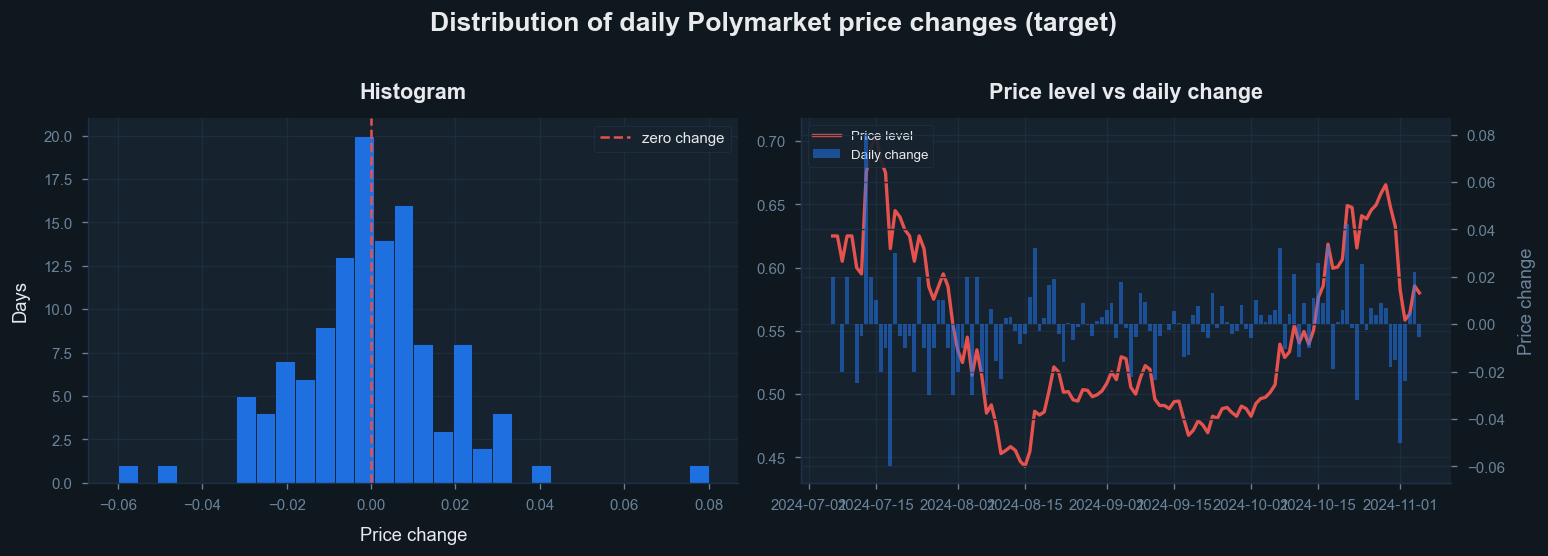

In [4]:
# ── Target variable: 1-day price change ──────────────────────────────────────
#
# We predict price_change[t] = price[t] - price[t-1]
#
# Why change instead of level?
#   In v1, predicting the price level let AR(1) (predict tomorrow = today)
#   dominate because Polymarket prices move slowly (~1-2 cents/day).
#   Predicting the CHANGE forces models to find genuine directional signal.
#   A naive baseline (predict 0) has MAE = mean(|actual change|).

df['price_change'] = df['polymarket_trump_prob'].diff()
TARGET = 'price_change'
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print(f"Target  : {TARGET}")
print(f"Mean    : {df[TARGET].mean():.5f}")
print(f"Std     : {df[TARGET].std():.5f}")
print(f"Max up  : {df[TARGET].max():.5f}  |  Max down: {df[TARGET].min():.5f}")
print(f"Days up : {(df[TARGET] > 0).mean():.1%}  |  "
      f"Days down: {(df[TARGET] < 0).mean():.1%}  |  "
      f"Unchanged: {(df[TARGET] == 0).mean():.1%}")
naive_mae = df[TARGET].abs().mean()
print(f"\nNaive baseline MAE (predict 0): {naive_mae:.5f}")
print("Every model must beat this to be useful.")

# Plot
fig, axes = styled_fig(1, 2, figsize=(13, 4.5),
    title="Distribution of daily Polymarket price changes (target)")
ax1, ax2 = axes

ax1.hist(df[TARGET], bins=30, color=DEMOCRAT, alpha=0.85, edgecolor=BG_DARK)
ax1.axvline(0, color=REPUBLICAN, lw=1.5, ls='--', label='zero change')
style_ax(ax1, xlabel='Price change', ylabel='Days', title='Histogram', grid_axis='y')
ax1.legend()

ax2.plot(df['date'], df['polymarket_trump_prob'], color=REPUBLICAN, lw=2, label='Price level')
ax2_r = ax2.twinx()
ax2_r.bar(df['date'], df[TARGET], color=DEMOCRAT, alpha=0.5, width=0.8, label='Daily change')
ax2_r.set_ylabel('Price change', color=TEXT_MUTED)
ax2_r.tick_params(colors=TEXT_MUTED)
style_ax(ax2, title='Price level vs daily change')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Feature sets

In [5]:
# Drop columns with >30% NaN
exclude_always = (['date', TARGET, 'polymarket_trump_prob'] +
                  (['bsky_text','reddit_text','news_text'] + TEXT_COLS if HAS_TEXT
                   else ['bsky_text','reddit_text','news_text'] if 'bsky_text' in df.columns else []))
numeric_candidates = [c for c in df.columns if c not in exclude_always
                      and df[c].dtype != object]
nan_frac = df[numeric_candidates].isnull().mean()
numeric_pool = nan_frac[nan_frac <= 0.30].index.tolist()

FEAT_AR = ['polymarket_trump_prob_lag1']

FEAT_SENTIMENT = [c for c in numeric_pool if any(x in c for x in
    ['sentiment', 'gap', 'surprise', 'attention_asym', 'interaction'])]

FEAT_SOCIAL = [c for c in numeric_pool if any(x in c for x in
    ['bsky_', 'reddit_', 'net_', 'echo_'])]

FEAT_NEWS  = [c for c in numeric_pool if 'news_' in c or 'topic_' in c]

FEAT_POLLS = [c for c in numeric_pool if any(x in c for x in
    ['poll_', 'event_', 'debate_', 'days_to_'])]

FEAT_MACRO = [c for c in numeric_pool if any(x in c for x in
    ['sp500_','oil_','vix_','bond_','usd_','macro_'])]

FEAT_ALL = list(set(FEAT_AR + FEAT_SENTIMENT + FEAT_SOCIAL +
                    FEAT_NEWS + FEAT_POLLS + FEAT_MACRO))

print(f"Feature pool after 30% NaN filter: {len(numeric_pool)} columns")
print(f"  AR                 : {len(FEAT_AR)}")
print(f"  Sentiment / new    : {len(FEAT_SENTIMENT)}")
print(f"  Social media       : {len(FEAT_SOCIAL)}")
print(f"  News               : {len(FEAT_NEWS)}")
print(f"  Polls / Events     : {len(FEAT_POLLS)}")
print(f"  Macro / Finance    : {len(FEAT_MACRO)}")
print(f"  ALL combined       : {len(FEAT_ALL)}")
if HAS_TEXT:
    print(f"  Text cols          : {len(TEXT_COLS)}  (fitted per fold via ColumnTransformer)")

Feature pool after 30% NaN filter: 95 columns
  AR                 : 1
  Sentiment / new    : 19
  Social media       : 28
  News               : 13
  Polls / Events     : 18
  Macro / Finance    : 32
  ALL combined       : 93
  Text cols          : 6  (fitted per fold via ColumnTransformer)


## Walk-forward CV splits

In [6]:
folds = get_cv_folds(df, n_splits=3, gap=1, test_days=14)
tv_idx, test_idx = get_test_split(df, test_days=14)

print("Walk-forward CV folds (expanding window, gap=1 day, 14-day held-out test):")
print_fold_summary(df, folds)
print(f"\nTest set: {df['date'].iloc[test_idx[0]].date()} -> "
      f"{df['date'].iloc[test_idx[-1]].date()}  ({len(test_idx)} rows)")

for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df, gap=1)
print("All folds pass leakage check.")

Walk-forward CV folds (expanding window, gap=1 day, 14-day held-out test):
Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-06    2024-08-01       27    2024-08-03    2024-08-29      27
   2    2024-07-06    2024-08-28       54    2024-08-30    2024-09-25      27
   3    2024-07-06    2024-09-24       81    2024-09-26    2024-10-22      27

Test set: 2024-10-23 -> 2024-11-05  (14 rows)
All folds pass leakage check.


## Helpers

In [7]:
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])


def make_text_pipeline(model, numeric_cols, text_cols,
                        n_components=5, max_features=200):
    """
    Mixed pipeline: numeric + candidate-specific TF-IDF branches.

    Correct fit/transform schema per fold:
      fit   on X_train rows  -> learns vocabulary + IDF from training days only
      transform X_val        -> same frozen vectorizer, no refitting

    TF-IDF settings for small corpora (35-80 training days):
      min_df=1         : keep terms appearing even once in training
      max_features=200 : tight cap reduces overfitting risk
      ngram_range=(1,2): unigrams + bigrams
      sublinear_tf=True: log(1+tf) dampens high-frequency stop-like terms
      n_components=5   : compact LSA per source (6 sources = 30 text features)
    """
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    text_transformers = []
    for col in text_cols:
        text_pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=max_features, min_df=1, max_df=0.98,
                ngram_range=(1, 2), sublinear_tf=True,
                stop_words='english',
            )),
            ('svd', TruncatedSVD(n_components=n_components, random_state=42)),
        ])
        text_transformers.append((f'text_{col}', text_pipe, col))

    ct = ColumnTransformer(
        transformers=[('numeric', numeric_transformer, numeric_cols)]
        + text_transformers,
        remainder='drop',
    )
    return Pipeline([('features', ct), ('model', model)])


def directional_accuracy(y_true, y_pred):
    """Fraction of non-zero-change days where the predicted direction is correct."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask]))


def score_fold(pipeline, feat_cols, train_idx, val_idx):
    X_tr = df.iloc[train_idx][feat_cols]
    y_tr = df.iloc[train_idx][TARGET].values
    X_va = df.iloc[val_idx][feat_cols]
    y_va = df.iloc[val_idx][TARGET].values
    p = clone(pipeline)
    p.fit(X_tr, y_tr)
    return mean_absolute_error(y_va, p.predict(X_va))


def eval_pipeline(pipeline, feat_cols, train_idx, val_idx):
    X_tr = df.iloc[train_idx][feat_cols]
    y_tr = df.iloc[train_idx][TARGET].values
    X_va = df.iloc[val_idx][feat_cols]
    y_va = df.iloc[val_idx][TARGET].values
    p = clone(pipeline)
    p.fit(X_tr, y_tr)
    y_pred = p.predict(X_va)
    return {
        'MAE':    mean_absolute_error(y_va, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_va, y_pred)),
        'R2':     r2_score(y_va, y_pred),
        'DirAcc': directional_accuracy(y_va, y_pred),
        'y_val':  y_va,
        'y_pred': y_pred,
    }


print("Helpers defined.")

Helpers defined.


## Hyperparameter tuning

In [8]:
# ── Parameter grids ───────────────────────────────────────────────────────────
# Walk-forward manual grid search: no sklearn GridSearchCV (it shuffles data).
# For text models, ColumnTransformer fits TF-IDF per fold automatically.

PARAM_GRIDS = {
    'AR(1)':          {'model__alpha': [1e-9], 'feats': [FEAT_AR]},
    'Ridge':          {'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000], 'feats': [FEAT_ALL]},
    'Lasso':          {'model__alpha': [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05, 0.1], 'feats': [FEAT_ALL]},
    'ElasticNet':     {'model__alpha': [1e-4, 0.001, 0.01, 0.1],
                       'model__l1_ratio': [0.1, 0.5, 0.9], 'feats': [FEAT_ALL]},
    'Lasso Sentiment':{'model__alpha': [1e-4, 0.001, 0.01, 0.1],
                       'feats': [FEAT_SENTIMENT + FEAT_POLLS + FEAT_AR]},
}
if HAS_XGB:
    PARAM_GRIDS['XGBoost'] = {
        'model__n_estimators': [50, 100], 'model__max_depth': [2, 3],
        'model__learning_rate': [0.05, 0.1], 'feats': [FEAT_ALL]}
if HAS_TEXT:
    PARAM_GRIDS['Lasso + Text'] = {
        'model__alpha': [1e-4, 0.001, 0.01, 0.05, 0.1],
        'feats': [FEAT_ALL], 'use_text': [True]}
    if HAS_XGB:
        PARAM_GRIDS['XGBoost + Text'] = {
            'model__n_estimators': [50, 100], 'model__max_depth': [2, 3],
            'model__learning_rate': [0.05, 0.1],
            'feats': [FEAT_ALL], 'use_text': [True]}

BASE_ESTIMATORS = {
    'AR(1)':           Ridge(),
    'Ridge':           Ridge(),
    'Lasso':           Lasso(max_iter=10000),
    'ElasticNet':      ElasticNet(max_iter=10000),
    'Lasso Sentiment': Lasso(max_iter=10000),
    'Lasso + Text':    Lasso(max_iter=10000),
}
if HAS_XGB:
    BASE_ESTIMATORS['XGBoost']        = XGBRegressor(random_state=42, verbosity=0)
    BASE_ESTIMATORS['XGBoost + Text'] = XGBRegressor(random_state=42, verbosity=0)

naive_mae_cv = df.iloc[np.concatenate([va for _, va in folds])][TARGET].abs().mean()
print(f"Naive baseline (predict 0) CV MAE = {naive_mae_cv:.5f}")
print()

tuning_results = {}
TUNED_MODELS   = {}

for model_name, grid in PARAM_GRIDS.items():
    feat_cols = grid.get('feats', [FEAT_ALL])[0]
    use_text  = bool(grid.get('use_text', [False])[0] if isinstance(
                    grid.get('use_text', False), list) else grid.get('use_text', False))

    param_keys = [k for k in grid if k.startswith('model__')]
    param_vals = [grid[k] for k in param_keys]

    def _make(estimator, _fc=feat_cols, _ut=use_text):
        if _ut:
            nc = [c for c in _fc if c not in TEXT_COLS]
            return make_text_pipeline(estimator, nc, TEXT_COLS)
        return make_pipeline(estimator)

    if model_name == 'AR(1)':
        pipe = make_pipeline(Ridge(alpha=1e-9))
        fold_maes = [score_fold(pipe, feat_cols, tr, va) for tr, va in folds]
        tuning_results[model_name] = {'best_mae': np.mean(fold_maes), 'best_params': {}}
        TUNED_MODELS[model_name] = (pipe, feat_cols, False)
        print(f"AR(1)                  fixed  |  CV MAE = {np.mean(fold_maes):.5f}")
        continue

    best_mae, best_params, best_pipe = np.inf, None, None
    all_combos = []
    for combo in itertools.product(*param_vals):
        params = dict(zip(param_keys, combo))
        est = clone(BASE_ESTIMATORS[model_name])
        est.set_params(**{k.replace('model__', ''): v for k, v in params.items()})
        pipe = _make(est)
        fc_eff = feat_cols + TEXT_COLS if use_text else feat_cols
        fold_maes = [score_fold(pipe, fc_eff, tr, va) for tr, va in folds]
        mean_mae = np.mean(fold_maes)
        all_combos.append({'params': params, 'mean_mae': mean_mae})
        if mean_mae < best_mae:
            best_mae, best_params, best_pipe = mean_mae, params, pipe

    eff_feats = feat_cols + TEXT_COLS if use_text else feat_cols
    tuning_results[model_name] = {'best_params': best_params, 'best_mae': best_mae,
                                   'all_results': all_combos}
    TUNED_MODELS[model_name] = (best_pipe, eff_feats, use_text)
    print(f"{model_name:<22} {len(all_combos):>3} combos  |  "
          f"best MAE={best_mae:.5f}  |  {best_params}")

print()
print("Tuning complete.")

Naive baseline (predict 0) CV MAE = 0.01009

AR(1)                  fixed  |  CV MAE = 0.01275


Ridge                    7 combos  |  best MAE=0.01115  |  {'model__alpha': 1000}


Lasso                    7 combos  |  best MAE=0.01030  |  {'model__alpha': 0.05}


ElasticNet              12 combos  |  best MAE=0.01030  |  {'model__alpha': 0.1, 'model__l1_ratio': 0.5}


Lasso Sentiment          4 combos  |  best MAE=0.01030  |  {'model__alpha': 0.1}


XGBoost                  8 combos  |  best MAE=0.01223  |  {'model__n_estimators': 50, 'model__max_depth': 3, 'model__learning_rate': 0.05}


Lasso + Text             5 combos  |  best MAE=0.01030  |  {'model__alpha': 0.05}


XGBoost + Text           8 combos  |  best MAE=0.01233  |  {'model__n_estimators': 50, 'model__max_depth': 3, 'model__learning_rate': 0.05}

Tuning complete.


## Walk-forward CV results

In [9]:
cv_results = []
for model_name, (pipeline, feat_cols, use_text) in TUNED_MODELS.items():
    for fold_i, (train_idx, val_idx) in enumerate(folds, 1):
        m = eval_pipeline(pipeline, feat_cols, train_idx, val_idx)
        cv_results.append({'Model': model_name, 'Fold': fold_i,
                           'MAE': m['MAE'], 'RMSE': m['RMSE'],
                           'R2': m['R2'], 'DirAcc': m['DirAcc']})

cv_df = pd.DataFrame(cv_results)
summary = (cv_df.groupby('Model')[['MAE','RMSE','R2','DirAcc']]
           .agg(['mean','std']).round(5))
summary.columns = ['_'.join(c) for c in summary.columns]
summary = summary.sort_values('MAE_mean')

print("Walk-forward CV -- tuned models (mean +/- std across 3 folds):")
print(f"Naive baseline (predict 0) MAE = {naive_mae_cv:.5f}")
print()
print(f"{'Model':<24} {'MAE':>14} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 68)
for m in summary.index:
    print(f"{m:<24} "
          f"{summary.loc[m,'MAE_mean']:.4f}+/-{summary.loc[m,'MAE_std']:.4f}  "
          f"{summary.loc[m,'RMSE_mean']:.4f}  "
          f"{summary.loc[m,'R2_mean']:>8.3f}  "
          f"{summary.loc[m,'DirAcc_mean']:>8.1%}")

Walk-forward CV -- tuned models (mean +/- std across 3 folds):
Naive baseline (predict 0) MAE = 0.01009

Model                               MAE     RMSE       R2    DirAcc
--------------------------------------------------------------------
ElasticNet               0.0103+/-0.0022  0.0137    -0.102     46.3%
Lasso                    0.0103+/-0.0022  0.0137    -0.102     46.3%
Lasso + Text             0.0103+/-0.0022  0.0137    -0.102     46.3%
Lasso Sentiment          0.0103+/-0.0022  0.0137    -0.102     46.3%
Ridge                    0.0112+/-0.0036  0.0147    -0.245     52.6%
XGBoost                  0.0122+/-0.0027  0.0169    -0.676     56.3%
XGBoost + Text           0.0123+/-0.0024  0.0160    -0.527     48.9%
AR(1)                    0.0127+/-0.0058  0.0160    -0.461     47.7%


## Results visualisation

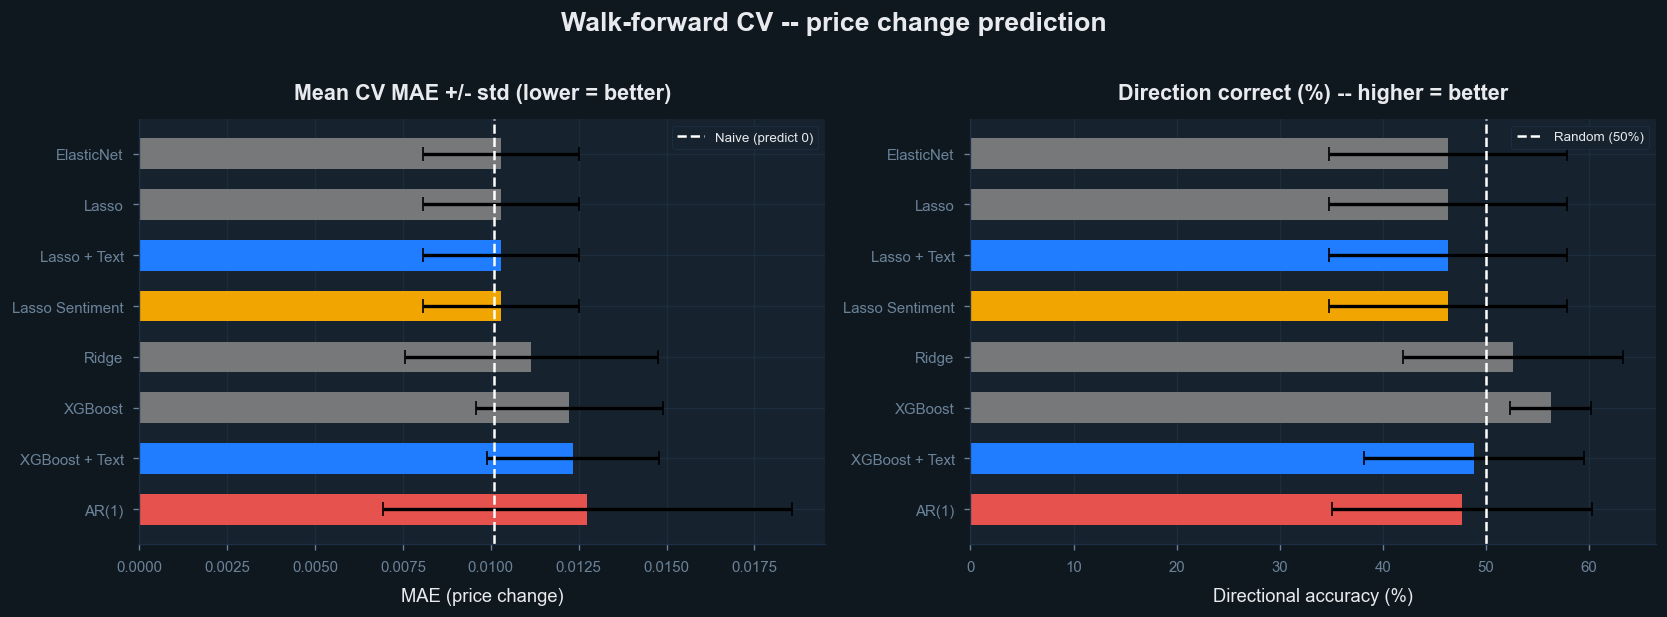

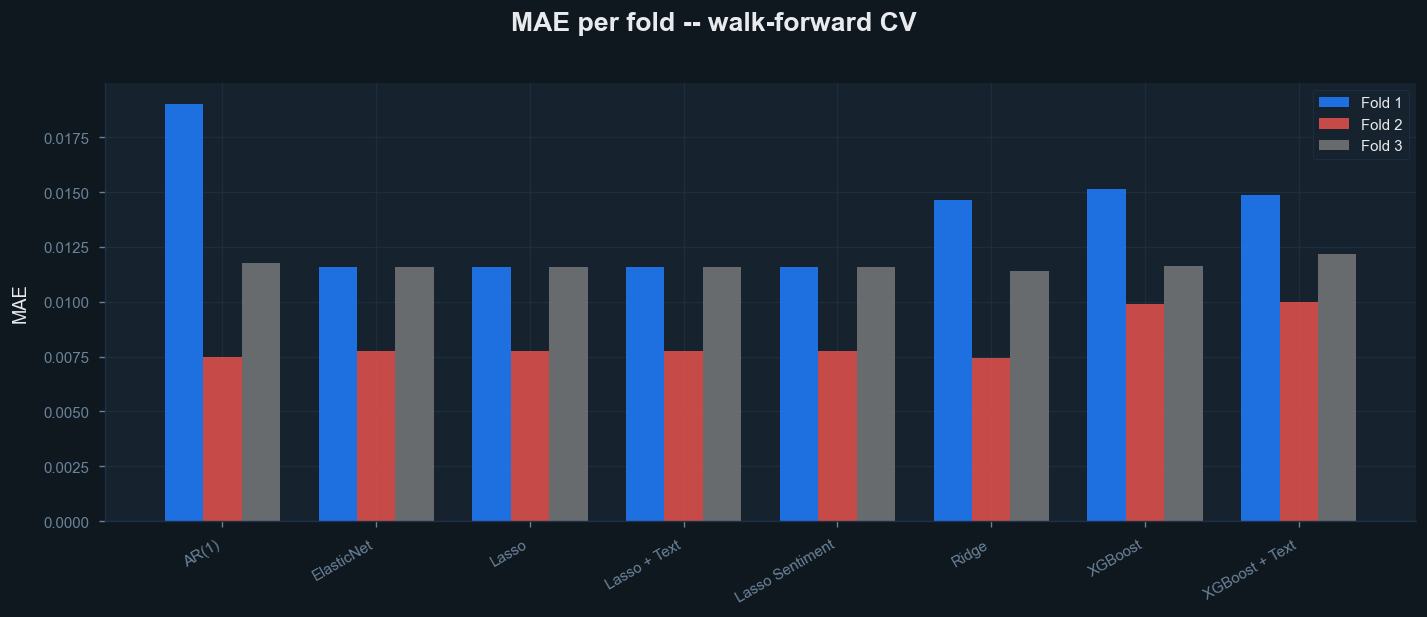

In [10]:
models_ord = summary.index.tolist()
means = summary['MAE_mean'].values
stds  = summary['MAE_std'].values

fig, axes = styled_fig(1, 2, figsize=(14, 5),
    title="Walk-forward CV -- price change prediction")
ax1, ax2 = axes

colors = [DEMOCRAT if 'Text' in m else REPUBLICAN if 'AR' in m
          else '#f0a500' if 'Sentiment' in m else NEUTRAL for m in models_ord]
ax1.barh(models_ord[::-1], means[::-1], xerr=stds[::-1],
         color=colors[::-1], capsize=4, height=0.6)
ax1.axvline(naive_mae_cv, color='white', ls='--', lw=1.5, label='Naive (predict 0)')
style_ax(ax1, xlabel='MAE (price change)', title='Mean CV MAE +/- std (lower = better)', grid_axis='x')
ax1.legend(fontsize=8)

dir_means = summary['DirAcc_mean'].values
dir_stds  = summary['DirAcc_std'].values
ax2.barh(models_ord[::-1], dir_means[::-1]*100, xerr=dir_stds[::-1]*100,
         color=colors[::-1], capsize=4, height=0.6)
ax2.axvline(50, color='white', ls='--', lw=1.5, label='Random (50%)')
style_ax(ax2, xlabel='Directional accuracy (%)',
         title='Direction correct (%) -- higher = better', grid_axis='x')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Per-fold breakdown
fig2, ax = styled_fig(1, 1, figsize=(12, 5),
    title="MAE per fold -- walk-forward CV")
fold_data = cv_df.pivot_table(index='Model', columns='Fold', values='MAE')
x = np.arange(len(fold_data))
w = 0.25
for fi, (fold, col) in enumerate(zip([1, 2, 3], [DEMOCRAT, REPUBLICAN, NEUTRAL])):
    if fold in fold_data.columns:
        ax.bar(x + fi*w, fold_data[fold], w, label=f'Fold {fold}', color=col, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(fold_data.index, rotation=30, ha='right', color=TEXT_PRIMARY)
style_ax(ax, ylabel='MAE', grid_axis='y')
ax.legend()
plt.tight_layout()
plt.show()

## Predictions vs actual (best model per fold)

Best model by CV MAE: ElasticNet


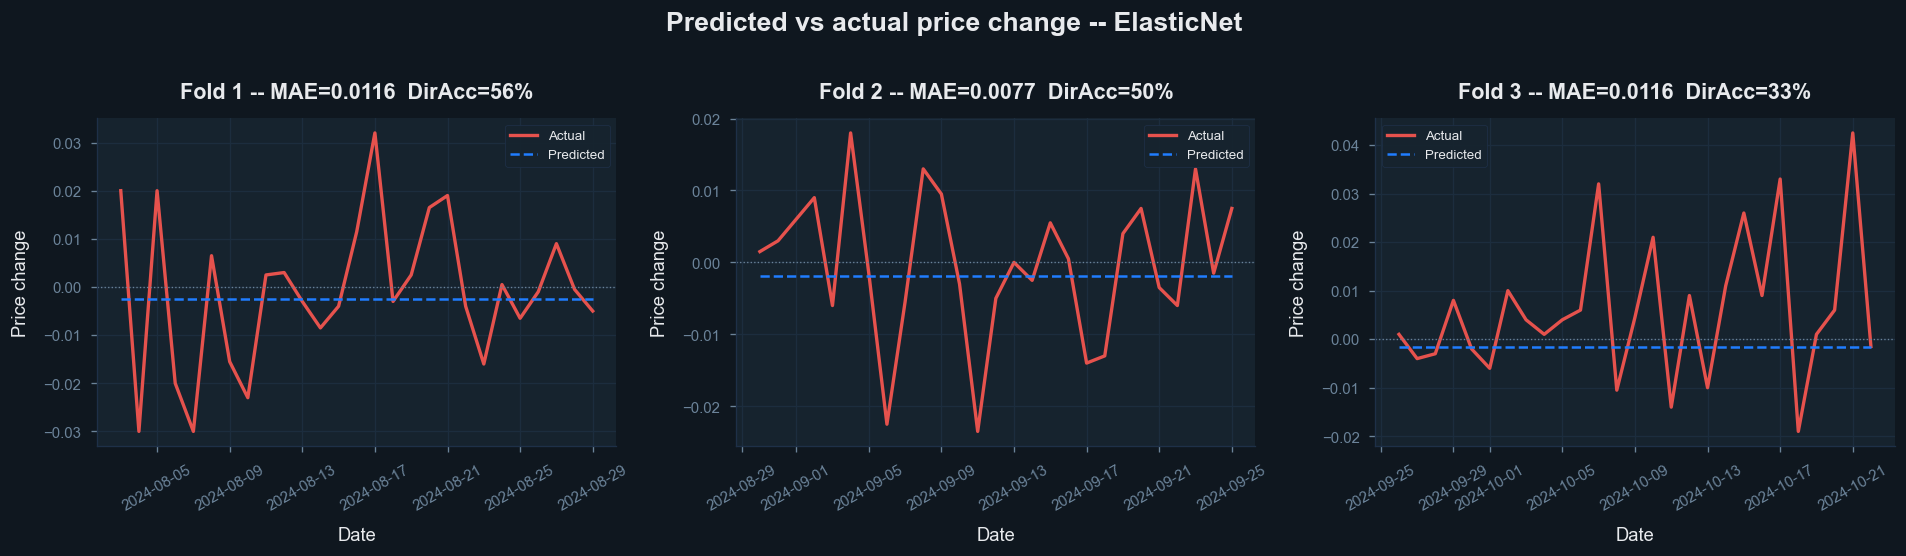

In [11]:
best_name = summary['MAE_mean'].idxmin()
best_pipe, best_feats, _use_text = TUNED_MODELS[best_name]
print(f"Best model by CV MAE: {best_name}")

fig, axes = styled_fig(1, 3, figsize=(16, 4.5),
    title=f"Predicted vs actual price change -- {best_name}")

for fi, (ax, (tr, va)) in enumerate(zip(axes, folds)):
    p = clone(best_pipe)
    p.fit(df.iloc[tr][best_feats], df.iloc[tr][TARGET])
    y_va = df.iloc[va][TARGET].values
    y_pr = p.predict(df.iloc[va][best_feats])
    dates = df.iloc[va]['date']
    ax.plot(dates, y_va, color=REPUBLICAN, lw=2, label='Actual')
    ax.plot(dates, y_pr, color=DEMOCRAT, lw=1.5, ls='--', label='Predicted')
    ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls=':')
    mae_f = mean_absolute_error(y_va, y_pr)
    da_f  = directional_accuracy(y_va, y_pr)
    style_ax(ax, xlabel='Date', ylabel='Price change',
             title=f'Fold {fi+1} -- MAE={mae_f:.4f}  DirAcc={da_f:.0%}')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Feature importance

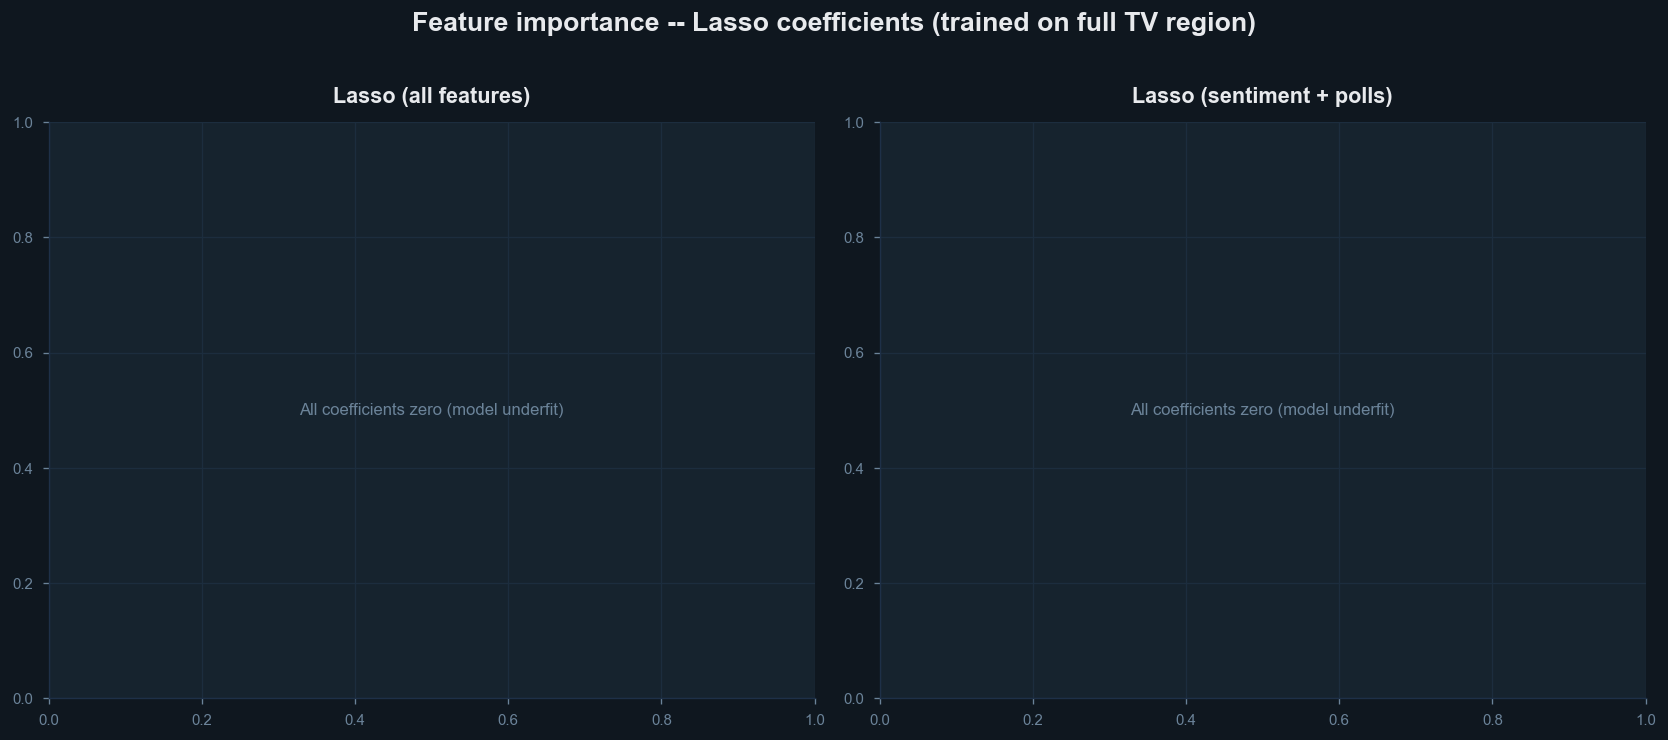

In [12]:
fig, axes = styled_fig(1, 2, figsize=(14, 6),
    title="Feature importance -- Lasso coefficients (trained on full TV region)")
ax1, ax2 = axes

for ax, mname, title in [(ax1, 'Lasso', 'Lasso (all features)'),
                          (ax2, 'Lasso Sentiment', 'Lasso (sentiment + polls)')]:
    if mname not in TUNED_MODELS:
        ax.text(0.5, 0.5, 'Not in TUNED_MODELS', ha='center', va='center',
                color=TEXT_MUTED, transform=ax.transAxes)
        continue
    pipe_m, feats_m, _ = TUNED_MODELS[mname]
    p = clone(pipe_m)
    p.fit(df.iloc[tv_idx][feats_m], df.iloc[tv_idx][TARGET])
    coefs = pd.Series(p['model'].coef_, index=feats_m)
    coefs = coefs[coefs != 0].sort_values(key=abs, ascending=False).head(20)
    if len(coefs) == 0:
        ax.text(0.5, 0.5, 'All coefficients zero (model underfit)',
                ha='center', va='center', color=TEXT_MUTED, transform=ax.transAxes)
        style_ax(ax, title=title)
        continue
    colors_c = [REPUBLICAN if v > 0 else DEMOCRAT for v in coefs.values]
    ax.barh(range(len(coefs)), coefs.values[::-1], color=colors_c[::-1])
    ax.set_yticks(range(len(coefs)))
    ax.set_yticklabels(coefs.index[::-1], color=TEXT_PRIMARY, fontsize=8)
    ax.axvline(0, color=TEXT_MUTED, lw=0.8)
    style_ax(ax, xlabel='Coefficient', title=title, grid_axis='x')
    patches = [mpatches.Patch(color=REPUBLICAN, label='+ve (bullish for Trump)'),
               mpatches.Patch(color=DEMOCRAT,   label='-ve (bearish for Trump)')]
    ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.show()

## Held-out test set evaluation

Final test set evaluation (14 held-out days):

Model                         MAE     RMSE       R2    DirAcc
------------------------------------------------------------
AR(1)                      0.0161   0.0202    0.004    50.0%
Ridge                      0.0156   0.0213   -0.113    50.0%
Lasso                      0.0162   0.0209   -0.067    50.0%
ElasticNet                 0.0162   0.0209   -0.067    50.0%
Lasso Sentiment            0.0162   0.0209   -0.067    50.0%


XGBoost                    0.0156   0.0200    0.024    64.3%


Lasso + Text               0.0162   0.0209   -0.067    50.0%


XGBoost + Text             0.0162   0.0201    0.013    64.3%


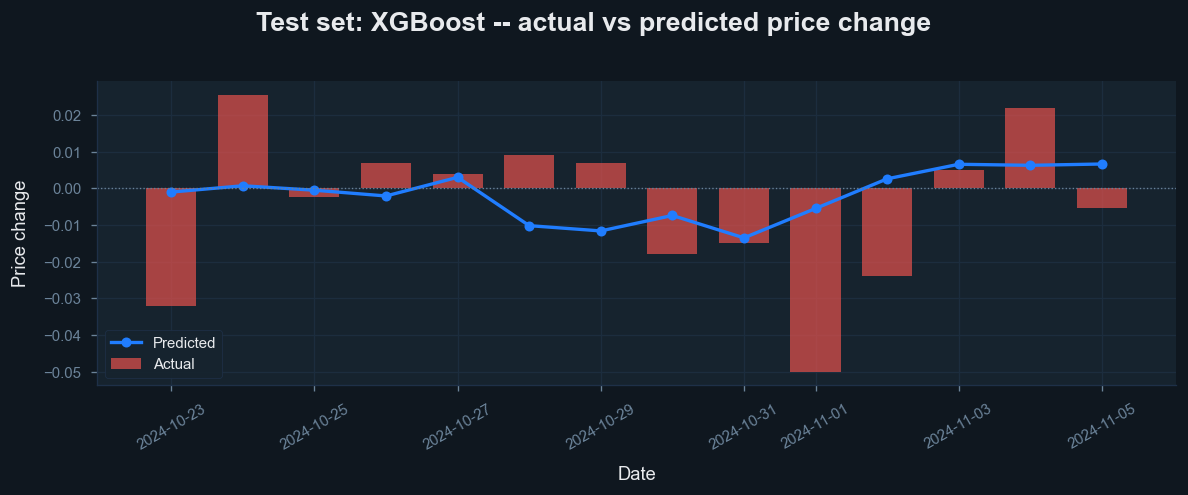

In [13]:
print("Final test set evaluation (14 held-out days):")
print()
print(f"{'Model':<24} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 60)

test_results = []
for model_name, (pipeline, feat_cols, _use_text) in TUNED_MODELS.items():
    p = clone(pipeline)
    p.fit(df.iloc[tv_idx][feat_cols], df.iloc[tv_idx][TARGET])
    y_pred = p.predict(df.iloc[test_idx][feat_cols])
    y_test = df.iloc[test_idx][TARGET].values
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    da   = directional_accuracy(y_test, y_pred)
    test_results.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse,
                         'R2': r2, 'DirAcc': da})
    print(f"{model_name:<24} {mae:>8.4f} {rmse:>8.4f} {r2:>8.3f} {da:>8.1%}")

test_df_res = pd.DataFrame(test_results).sort_values('MAE').reset_index(drop=True)

# Plot: actual vs predicted for best test model
best_test = test_df_res.iloc[0]['Model']
p2, f2, _ = TUNED_MODELS[best_test]
p2c = clone(p2)
p2c.fit(df.iloc[tv_idx][f2], df.iloc[tv_idx][TARGET])
y_tp = p2c.predict(df.iloc[test_idx][f2])
y_ta = df.iloc[test_idx][TARGET].values
test_dates = df.iloc[test_idx]['date']

fig, ax = styled_fig(1, 1, figsize=(10, 4),
    title=f"Test set: {best_test} -- actual vs predicted price change")
ax.bar(test_dates, y_ta, color=REPUBLICAN, alpha=0.7, width=0.7, label='Actual')
ax.plot(test_dates, y_tp, color=DEMOCRAT, lw=2, marker='o', markersize=5,
        label='Predicted')
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls=':')
style_ax(ax, xlabel='Date', ylabel='Price change', grid_axis='y')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Summary

In [14]:
print("=" * 65)
print("SUMMARY: models_v2 vs models_v1")
print("=" * 65)
print()
print(f"Target             : price CHANGE (v1 used price level)")
print(f"Naive baseline MAE : {naive_mae:.5f}  (predict 0 every day)")
print()
print("New features (all lag-1 safe):")
for f in ['bsky_sentiment_gap','news_sentiment_gap',
          'bsky_sent_surprise','news_sent_surprise','bsky_gap_surprise',
          'poll_margin_change','bsky_attention_asymmetry','interaction_sent_x_poll']:
    print(f"  {f}")
print()
print("Text improvements:")
print("  6 candidate-specific text columns (Trump / Harris per source)")
print("  TF-IDF: min_df=1, max_features=200, n_components=5 per source")
print("  -> 30 focused LSA features vs 30 noisy ones in v1")
print()
best_cv  = summary['MAE_mean'].idxmin()
best_dir = summary['DirAcc_mean'].idxmax()
print(f"Best CV MAE         : {best_cv}  ({summary.loc[best_cv,'MAE_mean']:.5f})")
print(f"Best directional acc: {best_dir}  ({summary.loc[best_dir,'DirAcc_mean']:.1%})")

SUMMARY: models_v2 vs models_v1

Target             : price CHANGE (v1 used price level)
Naive baseline MAE : 0.01272  (predict 0 every day)

New features (all lag-1 safe):
  bsky_sentiment_gap
  news_sentiment_gap
  bsky_sent_surprise
  news_sent_surprise
  bsky_gap_surprise
  poll_margin_change
  bsky_attention_asymmetry
  interaction_sent_x_poll

Text improvements:
  6 candidate-specific text columns (Trump / Harris per source)
  TF-IDF: min_df=1, max_features=200, n_components=5 per source
  -> 30 focused LSA features vs 30 noisy ones in v1

Best CV MAE         : ElasticNet  (0.01030)
Best directional acc: XGBoost  (56.3%)
